In [1]:
#import
import os
from keras import backend as K
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt 

In [2]:
os.chdir("./v_data/v_data")
img_width, img_height=224,224
train_data_dir='train'
validation_data_dir='test'
nb_train_samples=400
nb_validation_samples=100
epochs=15
batch_size=16
num_filters=8
filtre_size=3
if K.image_data_format() == 'channels_first':
    input_shape=(3,img_width,img_height)
else:
    input_shape=(img_width,img_height,3)
# print("on est sur:",os.getcwd())
# print(img_width , nb_train_samples, nb_train_smaples )

In [3]:
train_datagen= ImageDataGenerator(rescale=1./255,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
train_generator=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,class_mode='categorical')
validation_generator=test_datagen.flow_from_directory(
                        validation_data_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size, class_mode='categorical')


train_datagen1=ImageDataGenerator(rescale = 1. / 255)
test_datagen1=ImageDataGenerator(rescale=1./255)
train_generator1=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,class_mode='categorical')
validation_generator1=test_datagen.flow_from_directory(
                        validation_data_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size, class_mode='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [4]:
model=keras.Sequential()
model.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

model1=keras.Sequential()
model1.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model1.add(Activation('relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(24))
model1.add(Dense(2))
model1.add(Activation('sigmoid'))
print(model1.summary())

C:\Users\Dell Latitude 7430\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
model.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history=model.fit(train_generator,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator,
                    validation_steps=nb_validation_samples//batch_size)
model1.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history1=model1.fit(train_generator1,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator1,
                    validation_steps=nb_validation_samples//batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.5825 - loss: 12.6811 - val_accuracy: 0.7812 - val_loss: 1.2264
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.7150 - loss: 1.9711 - val_accuracy: 0.8646 - val_loss: 2.2728
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.8500 - loss: 0.7568 - val_accuracy: 0.9167 - val_loss: 0.3197
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.8450 - loss: 0.4912 - val_accuracy: 0.8542 - val_loss: 0.3305
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.8625 - loss: 0.4573 - val_accuracy: 0.8646 - val_loss: 0.3331
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.8700 - loss: 0.3410 - val_accuracy: 0.8750 - val_loss: 0.2810
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.8900 - loss: 0.3283 - val_accuracy: 0.8333 - val_loss: 0.2972
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.8900 - loss: 0.3140 - val_accuracy: 0

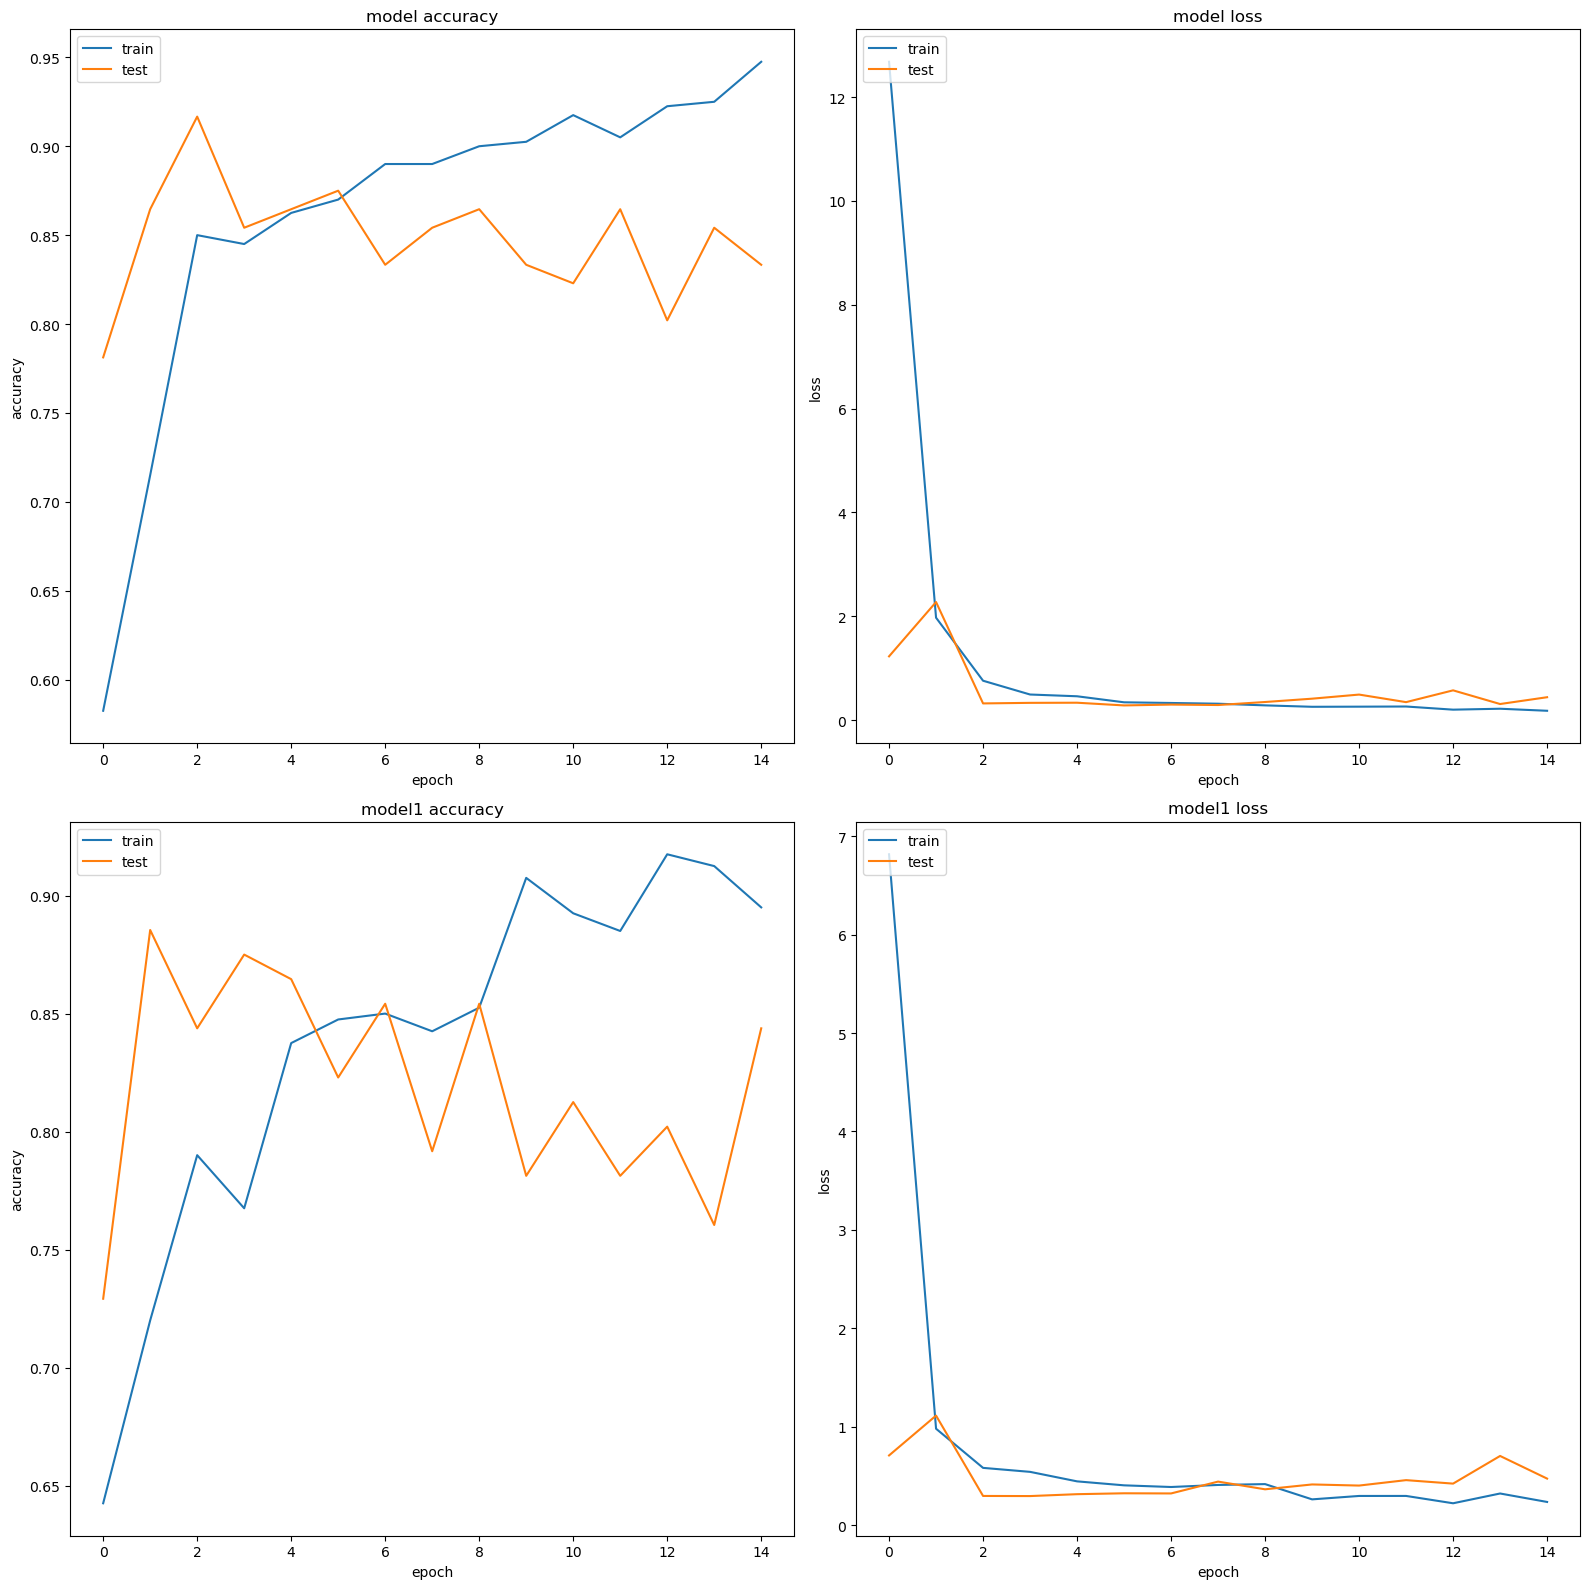

In [13]:
figure,ax=plt.subplots(2,2,figsize=(16,16))
ax[0,0].plot(history.history['accuracy'])
ax[0,0].plot(history.history['val_accuracy'])
ax[0,0].set_title('model accuracy')
ax[0,0].set_ylabel('accuracy')
ax[0,0].set_xlabel('epoch')
ax[0,0].legend(['train','test'],loc='upper left')

ax[0,1].plot(history.history['loss'])
ax[0,1].plot(history.history['val_loss'])
ax[0,1].set_title('model loss')
ax[0,1].set_ylabel('loss')
ax[0,1].set_xlabel('epoch')
ax[0,1].legend(['train','test'],loc='upper left')

ax[1,0].plot(history1.history['accuracy'])
ax[1,0].plot(history1.history['val_accuracy'])
ax[1,0].set_title('model1 accuracy')
ax[1,0].set_ylabel('accuracy')
ax[1,0].set_xlabel('epoch')
ax[1,0].legend(['train','test'],loc='upper left')

ax[1,1].plot(history1.history['loss'])
ax[1,1].plot(history1.history['val_loss'])
ax[1,1].set_title('model1 loss')
ax[1,1].set_ylabel('loss')
ax[1,1].set_xlabel('epoch')
ax[1,1].legend(['train','test'],loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
print(os.getcwd())
print(os.listdir())

C:\Users\Dell Latitude 7430\Desktop\Deep_learning_Work\v_data\v_data
['.ipynb_checkpoints', 'test', 'train', 'untitled.ipynb']
